# Imports

In [8]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)

from torch.optim import AdamW  # <-- correct optimizer import

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time


In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu


# Load your CSV files

In [12]:
DATA_DIR = "C:/Users/CSIS-PostGrad/multimodal_pipeline/Data"

train_df = pd.read_csv(os.path.join(DATA_DIR, "train_metadata_clean.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val_metadata_clean.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_metadata_clean.csv"))

LABEL_COL = "6_way_label"   # or 3_way_label, 2_way_label

MAX_LEN = 128
BATCH_SIZE = 16
LR = 1e-5
EPOCHS = 3
PATIENCE = 3   # early stopping patience

# Dataset Class

In [13]:
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, label_column, max_len=128):
        self.texts = df["clean_text"].astype(str).tolist()
        self.labels = df[label_column].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Tokenizer and DataLoaders

In [14]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

train_dataset = TextDataset(train_df, tokenizer, LABEL_COL, MAX_LEN)
val_dataset   = TextDataset(val_df, tokenizer, LABEL_COL, MAX_LEN)
test_dataset  = TextDataset(test_df, tokenizer, LABEL_COL, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\CSIS-PostGrad\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\CSIS-PostGrad\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

# Load DistilBERT model (CPU-friendly)

In [15]:
num_labels = train_df[LABEL_COL].nunique()

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
).to(DEVICE)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Early stopping class

In [16]:
class EarlyStopping:
    def __init__(self, patience=2):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None

    def step(self, loss, model):
        if loss < self.best_loss:
            self.best_loss = loss
            self.best_state = model.state_dict()
            self.counter = 0
        else:
            self.counter += 1

        return self.counter >= self.patience


# Training and Evaluation loops

In [17]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        optimizer.zero_grad()

        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.logits.argmax(dim=1)
        correct += (preds == batch["labels"]).sum().item()
        total += len(preds)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item()

            preds = outputs.logits.argmax(dim=1)
            correct += (preds == batch["labels"]).sum().item()
            total += len(preds)

    return total_loss / len(loader), correct / total


# Train model

In [18]:
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
early_stop = EarlyStopping(patience=PATIENCE)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{EPOCHS} =====")

    t0 = time.time()

    train_loss, train_acc = train_epoch(model, train_loader, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f" Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f" Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f" Time: {time.time() - t0:.1f}s")

    if early_stop.step(val_loss, model):
        print("Early stopping triggered")
        break

model.load_state_dict(early_stop.best_state)
print("\nBest model restored.")



===== Epoch 1/3 =====
 Train Loss: 0.6247 | Train Acc: 0.7767
 Val Loss:   0.5353 | Val Acc:   0.8082
 Time: 73286.7s

===== Epoch 2/3 =====
 Train Loss: 0.4761 | Train Acc: 0.8306
 Val Loss:   0.5157 | Val Acc:   0.8184
 Time: 69834.1s

===== Epoch 3/3 =====
 Train Loss: 0.3879 | Train Acc: 0.8623
 Val Loss:   0.5343 | Val Acc:   0.8198
 Time: 69698.7s

Best model restored.


# Plot learning curves

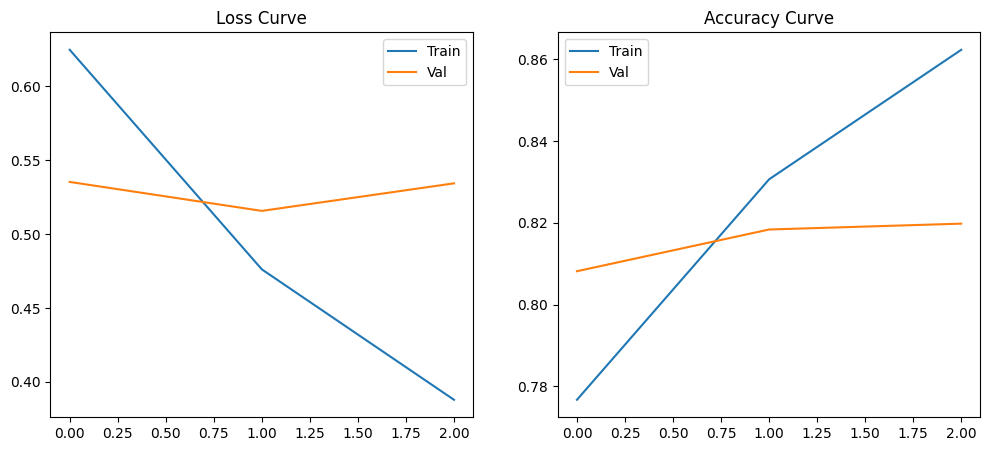

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


# Evaluation on test set


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87     23507
           1       0.77      0.65      0.71      3514
           2       0.76      0.70      0.73     11297
           3       0.80      0.46      0.59      1224
           4       0.82      0.88      0.85     17472
           5       0.82      0.80      0.81      2305

    accuracy                           0.82     59319
   macro avg       0.80      0.73      0.76     59319
weighted avg       0.82      0.82      0.82     59319



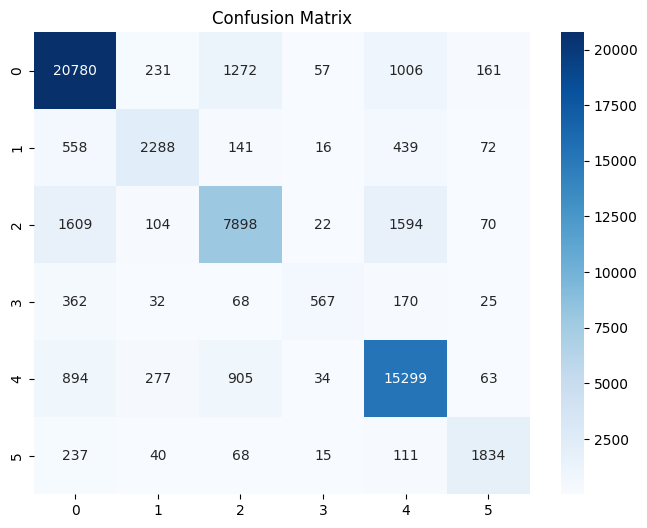

In [20]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
